# 01 — PM alone, on the v2 simulation suite

> Run top to bottom.

First notebook on the BLEUDEV-334 architecture (`thoughts/simulation-suite-v2-requirements.md`):
every trading agent — the Portfolio Manager, a competing strategy, organic noise — is a
`Strategy` plugged into one shared `BasketWorld`, instead of separate one-off scripts per
scenario. This notebook is the R1 baseline: PM alone, no competitors, no basket-mates —
does the weighted-curve pricing (`PRICING.md`) plus the fee + gas-cost profitability gate
(`ADR-0006`) hold a synthetic WETH/USDC pair near its declared 50/50 target?

**Prices are synthetic-only** (R2): a driftless GBM path, parametrized directly by
volatility per step — no historical or live market data anywhere in this suite.

Uses `aqua_sim.scenarios.pm_alone.build_world` directly — the scenario builder itself,
not a copy of its logic, so this notebook can't drift from what the scenario-level
regression tests (`tests/test_scenarios.py`) actually check.

In [1]:
import numpy as np

from aqua_sim.scenarios import pm_alone

N_STEPS = 2000
N_SEEDS = 10

mean_tes = []
for seed in range(N_SEEDS):
    world = pm_alone.build_world(seed=seed)
    world.run(N_STEPS)
    mean_te = np.mean(world.metrics.tracking_error_path)
    mean_tes.append(mean_te)
    print(f"seed {seed}: mean tracking error = {mean_te:.4%}")

mean_tes = np.array(mean_tes)
print(f"\nacross {N_SEEDS} seeds: mean={mean_tes.mean():.4%}, max={mean_tes.max():.4%}")

assert mean_tes.max() < 0.01, "PM alone should track tight on every seed -- no tolerance band, corrects whenever profitable"
print("\nOK: PM alone holds tight to its declared target on every seed tested")

seed 0: mean tracking error = 0.0002%
seed 1: mean tracking error = 0.0003%
seed 2: mean tracking error = 0.0002%
seed 3: mean tracking error = 0.0003%
seed 4: mean tracking error = 0.0003%
seed 5: mean tracking error = 0.0002%
seed 6: mean tracking error = 0.0002%
seed 7: mean tracking error = 0.0003%
seed 8: mean tracking error = 0.0002%
seed 9: mean tracking error = 0.0002%

across 10 seeds: mean=0.0002%, max=0.0003%

OK: PM alone holds tight to its declared target on every seed tested


## Why there's no knob to tune here

`PortfolioManagerStrategy`'s config carries only `fee` and `gas_cost` — matching
`ADR-0006`'s actual decision (no tolerance band, no rate cap: a real sweep found neither
reduces cost once correction is gated on realistic gas economics). PM corrects whenever
doing so is profitable, every step, both directions tried — there's nothing left to sweep
in this scenario, which is why one run per seed is enough to characterize it.

`GroupBoundaryGuard` is present but exercises nothing here — PM is the only registered
`Strategy`, so no trade is ever a candidate for crossing a group boundary. `03_guard_enforcement.ipynb`
is where the guard actually gets tested.

## Visual

Tracking error over the run, one representative seed — the sawtooth is the drift-then-
correct pattern: price moves, PM's quote skews away from target, a correction fires once
it's profitable net of fee+gas, error drops back near zero.

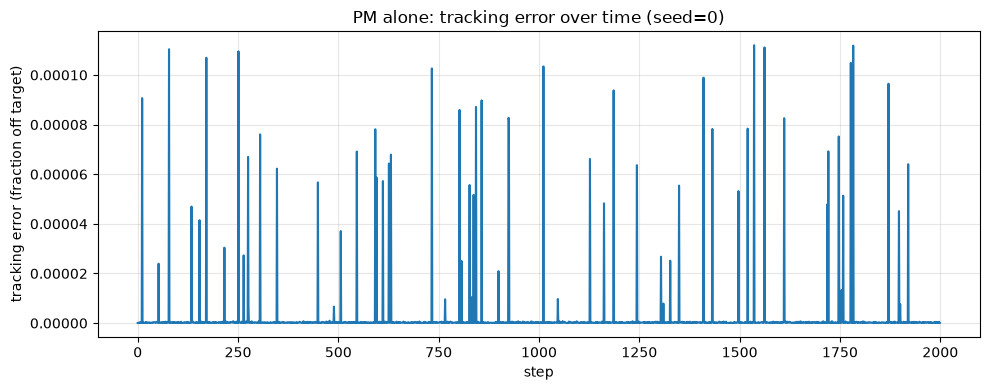

In [2]:
import matplotlib.pyplot as plt

world = pm_alone.build_world(seed=0)
world.run(N_STEPS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(world.metrics.tracking_error_path)
ax.set_xlabel("step")
ax.set_ylabel("tracking error (fraction off target)")
ax.set_title("PM alone: tracking error over time (seed=0)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

PM alone, no competitors, no basket-mates: mean tracking error stays under 1% on every
seed tested, with no tunable knob beyond `fee`/`gas_cost` — matching `ADR-0006`'s decision
and the R1 requirement in `thoughts/simulation-suite-v2-requirements.md`. This is the
baseline the other two v2 notebooks build on:

- `02_basket_with_without_pm.ipynb` — what happens once a competing strategy shares PM's
  basket group, with and without PM correcting (R5).
- `03_guard_enforcement.ipynb` — what happens when a competing strategy tries to cross a
  group boundary instead (R6).